<a href="https://colab.research.google.com/github/ajaykumar080286/MachineLearning/blob/main/31_perceptron_trick_sigmoid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification

In [4]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=20)

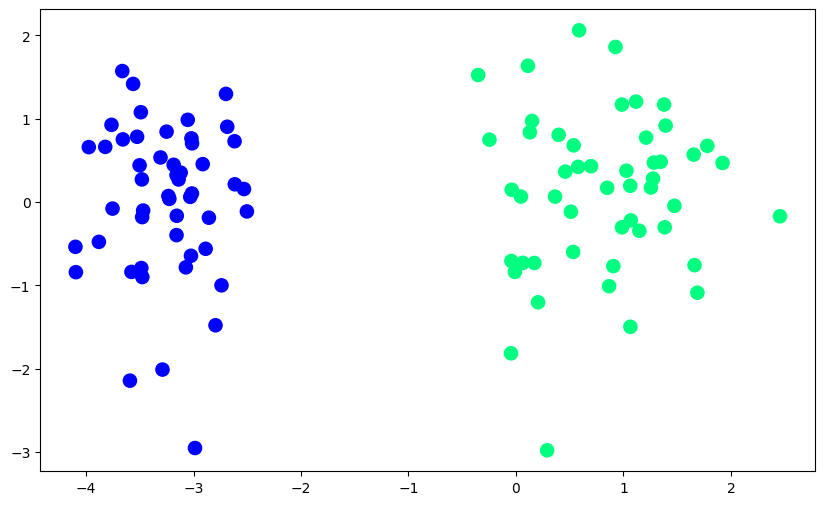

In [7]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter', s=90)


In [10]:

def preceptron(X,y):

  lr=0.1
  epochs=500

  X=np.insert(X,0,1,axis=1)
  weights=np.ones(X.shape[1])

  for i in range(epochs):

    idx=np.random.randint(0,X.shape[0])
    y_hat=step(np.dot(X[idx],weights))
    weights=weights+lr*(y[idx]-y_hat)*X[idx]

  return weights[0],weights[1:]

In [11]:
def step(z):
  return 1 if z>0 else 0

In [12]:
intercept_,coef_=preceptron(X,y)

In [13]:
m=-(coef_[0]/coef_[1])
b=-(intercept_/coef_[1])

In [14]:
X_input=np.linspace(-3,3,100)
y_imput=m*X_input+b

(-3.0, 2.0)

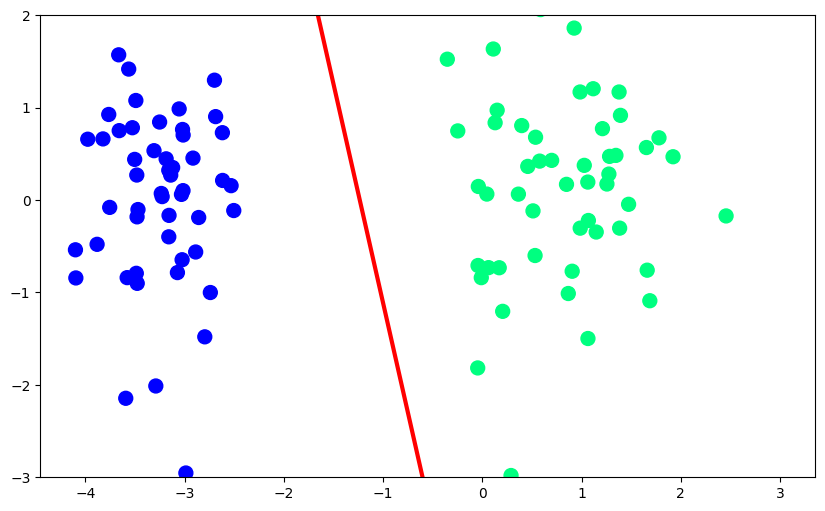

In [15]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.plot(X_input,y_imput,color='red',linewidth=3)
plt.ylim(-3,2)


In [16]:
lr=LogisticRegression()
lr.fit(X,y)
coef_=lr.coef_
intercept_=lr.intercept_


In [17]:
a=coef_[0][0]
b=coef_[0][1]
c=intercept_
m=-(a/b)
d=-(c/b)

In [18]:
y_input1=m*X_input+d

(-3.0, 2.0)

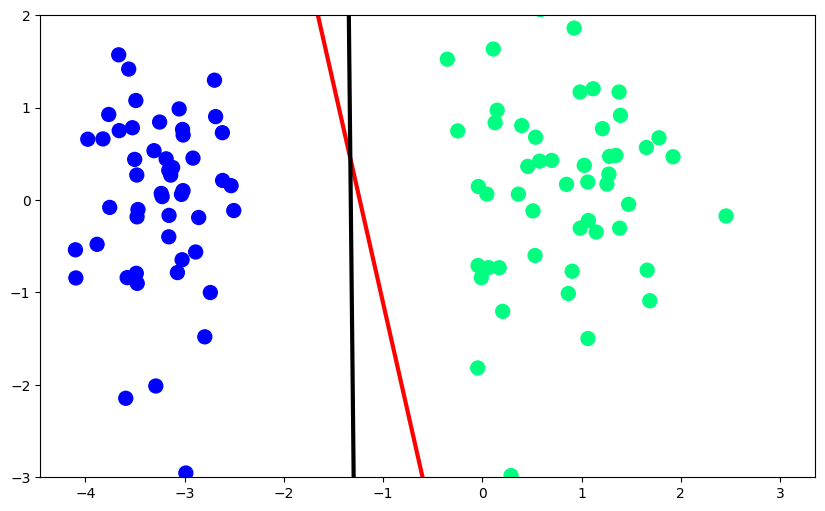

In [19]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.plot(X_input,y_imput,color='red',linewidth=3)
plt.plot(X_input,y_input1,color='black',linewidth=3)

plt.ylim(-3,2)

In [31]:
def preceptron_sig(X,y):

  lr=0.1
  epochs=500

  X=np.insert(X,0,1,axis=1)
  weights=np.ones(X.shape[1])

  for i in range(epochs):

    idx=np.random.randint(0,X.shape[0])
    y_hat=sigmoid(np.dot(X[idx],weights))
    weights=weights+lr*(y[idx]-y_hat)*X[idx]

  return weights[0],weights[1:]

In [32]:
def sigmoid(z):
  return 1/(1+np.exp(-z))

In [33]:
intercept_,coef_=preceptron_sig(X,y)

In [34]:
m=-(coef_[0]/coef_[1])
b=-(intercept_/coef_[1])
y_imput2=m*X_input+b


(-3.0, 2.0)

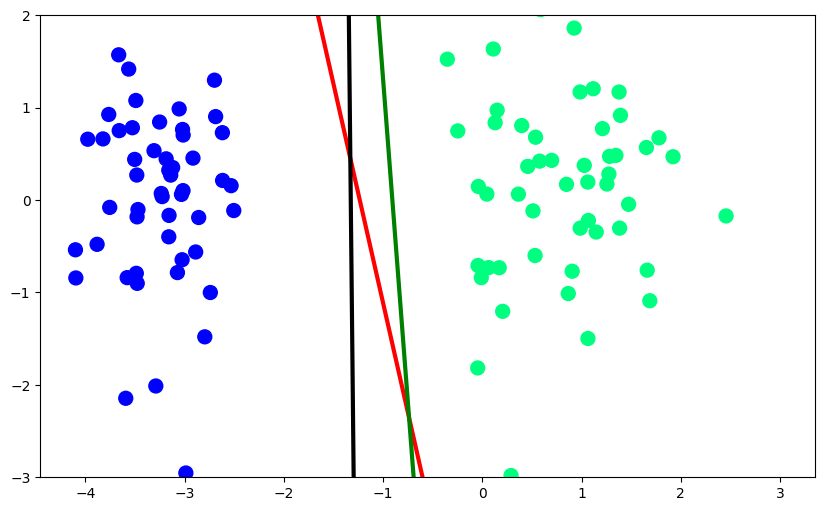

In [35]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.plot(X_input,y_imput,color='red',linewidth=3)
plt.plot(X_input,y_input1,color='black',linewidth=3)
plt.plot(X_input,y_imput2,color='green',linewidth=3)

plt.ylim(-3,2)
